# 0. Import relevant packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pysammos.data_handle.contacts.complete.branch_vectors as bv

In [ ]:
import pysammos.data_handle.contacts.complete.coordination_number as cn

In [83]:
import pysammos.data_handle.contacts.qualitycheck.duplicates as dq  

In [94]:
import pysammos.data_handle.particles.particle_stats as ps

# 1. Contacts

## 1.1. Complete

### 1.1.1. Branch Vectors

In [65]:
# Example 1: Simple branch and center-to-center vectors in 2D

# Inputs
r_A = np.array([[1, 2.0]])
r_B = np.array([[2, 2.0]])
contact_A = np.array([[1.5, 2.0]])
L = np.array([3.0])
periodic = np.array([True, True])
# Outputs
BV, d = bv.from_contacts(r_A, r_B, contact_A, L, periodic)
BV, d

(array([[-0.5,  0. ]]), array([[-1.,  0.]]))

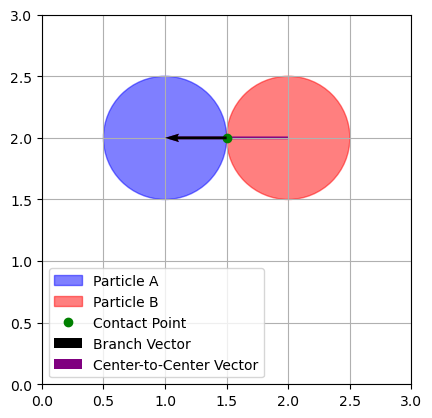

In [66]:
# plot the two particles as circles 
fig, ax = plt.subplots()
radius_a = 0.5
radius_b = 0.5

circle_a = plt.Circle(r_A[0], radius_a, color='blue', alpha=0.5, label='Particle A'); ax.add_artist(circle_a)
circle_b = plt.Circle(r_B[0], radius_b, color='red', alpha=0.5, label='Particle B'); ax.add_artist(circle_b)
ax.set_xlim(0, 3); ax.set_ylim(0, 3)
ax.set_aspect('equal', adjustable='box')
# plot the contact point
ax.plot(contact_A[0,0], contact_A[0,1], 'go', label='Contact Point')
# plot the branch vector    
ax.quiver( contact_A[0,0], contact_A[0,1], BV[0,0], BV[0,1], angles='xy', scale_units='xy', scale=1, 
          color='black', label='Branch Vector', zorder=4)
# plot the center-to-center vector
ax.quiver(r_B[0,0], r_B[0,1], d[0,0], d[0,1], angles='xy', scale_units='xy', scale=1, 
          color='purple', label='Center-to-Center Vector')

plt.legend()
plt.grid()
plt.show()


### 1.1.2. Coordination number

In [81]:
# Example: Coordination number calculation

LL_dup= np.array([1, 2, 1, 2, 1, 3,]) # Particle IDs
ID = np.array([1,2,3]) # Particle ID list

# Count coordination numbers
coord_numbers = cn.count(LL_dup, ID)
coord_numbers


(array([3, 2, 1]), array([3, 2]))

## 1.2. Quality Check

In [88]:
# Example of duplicate removal

# Inputs
Particle_A_LL = np.array([1, 2, 1, 4, 1, 3, 7])  # Particle A IDs with duplicates
Particle_B_LL = np.array([2, 1, 2, 3, 3, 1, 4])  # Particle B IDs with duplicates


# Get unique pairs
keep_indices = dq.get_unique_pairs(Particle_A_LL, Particle_B_LL)
keep_indices


array([0, 3, 4, 6])

## 1.3. Particle Mapper (concept)

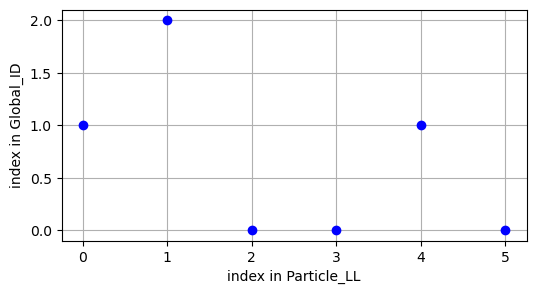

In [114]:
# Example arrays
Global_ID = np.array([1, 2, 3]) # particle data IDs
Particle_LL =  np.array([2, 3, 1, 1, 2, 1]) # IDs of particles in contacts 

# Find equivalence in ID indices
inds_glob_LL = np.searchsorted(Global_ID, Particle_LL)
valid_LL = Global_ID[inds_glob_LL] == Particle_LL # safeguard for invalid IDs
inds_glob_LL = inds_glob_LL[valid_LL] # filter invalid IDs if any

# Visualise the mapping
plt.figure(figsize=(6, 3))
plt.xlabel('index in Particle_LL')
plt.ylabel('index in Global_ID')
plt.scatter(np.arange(len(Particle_LL)), inds_glob_LL, c='blue', zorder = 3)
plt.grid(True)
plt.show()


# 2. Particles

d50: 0.3375


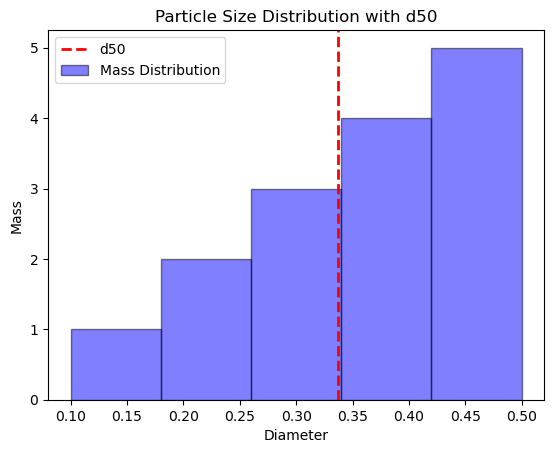

In [102]:
diameters = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
masses = np.array([1, 2, 3, 4, 5])
d50 = ps.d50_calc(diameters, masses)
print(f"d50: {d50}")
# plot
plt.hist(diameters, bins=5, weights=masses, alpha=0.5, color='blue', edgecolor='black')
plt.axvline(d50, color='red', linestyle='dashed', linewidth=2)
plt.title('Particle Size Distribution with d50')
plt.xlabel('Diameter')
plt.ylabel('Mass')
plt.legend(['d50', 'Mass Distribution'])
plt.show()